In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.interpolate import PchipInterpolator
from scipy.io import loadmat

from dataclasses import dataclass, replace

# set plot showing style
%config InlineBackend.figure_format = 'retina'

# load self-defined modules
%load_ext autoreload
%autoreload 2
from src.model import ModelParameters, ConsolidationParameters, HebbianSequenceModel
from src.experiment import build_exp_graph, make_trials, random_walk
from src.plotNet import make_kk_layout, plot_original_network, plot_learned_network
from src.plotBehav import plot_day1_byType, plot_day2_byType, plot_delta_byType

import statsmodels.api as sm
import statsmodels.formula.api as smf
from tqdm.auto import tqdm
import pickle

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
palette_whole = sns.color_palette('Paired', 12)
my_color = [palette_whole[i] for i in [0, 2, 6, 4]]
my_color_s2 = [palette_whole[i] for i in [1, 3, 7, 5]]

In [5]:
def load_design(subj):
    inFolder = 'C:\\Users\\Zhou Xiaoyue\\OneDrive - University College London\\Guenevere\\UCL\\Ph.D.project\\code.exp\\design\\'
    filename = inFolder + 'des_{}_subj.mat'.format(subj)
    des = loadmat(filename)
    
    expo_seq = des['dm_expo']['stim_seq'][0,0]
    trials_s1 = des['dm_2AFC']['seq_mat'][0,0]
    trials_s2 = des['dm_2AFC_conso']['seq_mat'][0,0]
    
    return expo_seq-1, trials_s1-1, trials_s2-1  # adjust index difference

def load_result(subj):
    inFolder = 'C:\\Users\\Zhou Xiaoyue\\OneDrive - University College London\\Guenevere\\UCL\\Ph.D.project\\code.exp\\data_batch2\\'

    # session 1
    filename = inFolder + 'ForcedChoice_{}_subj.mat'.format(subj)
    dat = loadmat(filename)

    rt = dat['result_2AFC']['rt'][0,0]
    answ = dat['result_2AFC']['answ'][0,0]
    resp = dat['result_2AFC']['resp'][0,0]

    result_s1 = pd.DataFrame({
        'rt': rt.ravel().astype(float),
        'answ': -1 * answ.ravel().astype(int) + 2,
        'resp': -1 * resp.ravel().astype(int) + 2
    })

    # session 2
    filename = inFolder + 'ForcedChoice_{}_subj_conso.mat'.format(subj)
    dat = loadmat(filename)

    rt = dat['result_2AFC']['rt'][0,0]
    answ = dat['result_2AFC']['answ'][0,0]
    resp = dat['result_2AFC']['resp'][0,0]

    result_s2 = pd.DataFrame({
        'rt': rt.ravel().astype(float),
        'answ': -1 * answ.ravel().astype(int) + 2,
        'resp': -1 * resp.ravel().astype(int) + 2
    })

    result_s1['session'] = 'S1'
    result_s1['trial'] = np.arange(0, 400).astype(int)
    result_s2['session'] = 'S2'
    result_s2['trial'] = np.arange(0, 400).astype(int)

    return pd.concat([result_s1, result_s2])

def seqMat_to_trials(seq_mat, adjacency, community):
    n_trial = seq_mat.shape[0]
    trial = np.arange(0,400)
    block = trial // 80
    cue = seq_mat[:,-2].astype(int)
    target = seq_mat[:,-1].astype(int)

    legal = adjacency[cue, target].astype(bool)
    within = community[cue] == community[target]
    sequence = seq_mat.astype(int)
    sequence = [row.tolist() for row in sequence]

    membership_lab = np.where(within, 'within', 'between')
    legal_lab = np.where(legal, 'legal', 'illegal')
    trial_type = np.char.add(membership_lab, '_')
    trial_type = np.char.add(trial_type, legal_lab)

    df = pd.DataFrame({
        'trial': trial,
        'trial_in_block': np.tile(np.arange(80), 5),
        'block': block,
        'cue': cue,
        'target': target,
        'legal': legal,
        'within': within,
        'sequence': sequence,
        'trial_type': trial_type
    })
    return df

In [6]:
def simulate_analytic_one_beta(beta, subj_list, adjacency, community, session):
    adjacency = np.asarray(adjacency, dtype=float)
    A = adjacency / adjacency.sum(axis=1, keepdims=True)
    gamma = np.exp(-beta)
    I = np.eye(A.shape[0])

    # annalytical solution
    A_app = (1 - gamma) * A @ np.linalg.inv(I - gamma * A)

    subject_table = []
    for subj in subj_list:
        _, trials_s1, trials_s2 = load_design(subj)
        if session == 'S1':
            trials = seqMat_to_trials(
                trials_s1,
                adjacency=adjacency,
                community=community
            )
        elif session == 'S2':
            trials = seqMat_to_trials(
                trials_s2,
                adjacency=adjacency,
                community=community
            )
        else:
            raise(ValueError('Wrong session string - should be either S1 or S2.'))

        result = load_result(subj)
        result = result[result['session'] == session]

        grand = pd.concat([trials, result], axis=1)
        # remove time-out trials
        grand = grand.loc[grand['resp'].isin([0,1])].copy()
        grand['subj'] = str(subj)
        subject_table.append(grand)


    output = pd.concat(subject_table, ignore_index=True)
    output['familiarity'] = A_app[output['cue'].to_numpy(), output['target'].to_numpy()]
    return output

In [7]:
def simulate_one_beta(beta, subj_list, adjacency, community):
    subject_table = []
    for subj in subj_list:
        # load relevent data
        expo_seq, trials_s1, trials_s2 = load_design(subj)
        result = load_result(subj)
        result_s1 = (
            result
            .loc[result["session"] == "S1"]
            .copy()
            .reset_index(drop=True)
        )
        result_s2 = (
            result
            .loc[result["session"] == "S2"]
            .copy()
            .reset_index(drop=True)
        )
        trials_s1 = seqMat_to_trials(
            trials_s1,
            adjacency=adjacency,
            community=community
        )
        trials_s2 = seqMat_to_trials(
            trials_s2,
            adjacency=adjacency,
            community=community
        )

        # create a new model for each subject
        params = ModelParameters(
            beta = float(beta),
            lr = 1.0,
            # frozen test
            lr_test_prefix=0.0,
            lr_test_probe=0.0,
            reset_current_activity=True,
            criterion_offset=0.0
        )
        model = HebbianSequenceModel(
            n_nodes=adjacency.shape[0],
            params=params
        )

        # learn exposure
        model.learn_exposure(expo_seq[0,:])
        model.learn_exposure(expo_seq[1,:])

        sim_s1 = model.run_test_phase(trials_s1)
        sim_s2 = model.run_test_phase(trials_s2)

        if len(sim_s1) != len(result_s1):
            raise ValueError(
                f"Subject {subj}: "
                f"{len(sim_s1)} model trials but "
                f"{len(result_s1)} behavioral trials."
            )
        
        if len(sim_s2) != len(result_s2):
            raise ValueError(
                f"Subject {subj}: "
                f"{len(sim_s2)} model trials but "
                f"{len(result_s2)} behavioral trials."
            )
        
        # merge dataset
        grand1 = pd.concat([result_s1, sim_s1], axis=1)
        grand2 = pd.concat([result_s2, sim_s2], axis=1)

        # remove timeout trials
        grand1 = grand1.loc[
            grand1["resp"].isin([0, 1])
        ].copy()
        grand2 = grand2.loc[
            grand2["resp"].isin([0, 1])
        ].copy()

        # add subject idx
        grand1['subj'] = subj
        grand2['subj'] = subj

        subject_table.append(grand2)
    
    return pd.concat(subject_table, ignore_index=True)



In [8]:
def fit_one_beta(df):
    fam_mean = df["familiarity"].mean()
    fam_sd = df["familiarity"].std(ddof=0)

    df["model_fam_z"] = (df["familiarity"] - fam_mean) / fam_sd

    fit = smf.glm(
        formula="resp ~ model_fam_z + C(subj)",
        data=df,
        family=sm.families.Binomial()
    ).fit(
        maxiter=200,
        disp=False
    )

    return {
        "logLik": float(fit.llf),
        "AIC": float(fit.aic),
        "BIC_llf": float(fit.bic_llf),
        "slope": float(
            fit.params["model_fam_z"]
        ),
        "slope_se": float(
            fit.bse["model_fam_z"]
        ),
        "slope_p": float(
            fit.pvalues["model_fam_z"]
        ),
        "n_trial": int(fit.nobs),
        "converged": bool(fit.converged),
        "fam_mean": float(fam_mean),
        "fam_sd": float(fam_sd)
    }

In [9]:
def bootstrap_subject(full_tbl, sampled_subj):
    # resample from full_tbl, based on sampled_subj
    # remember to assign new subject index to resampled tbl
    resampled_tbl = []
    for iSubj, subj in enumerate(sampled_subj):
        subj_tbl = full_tbl[full_tbl['subj'] == str(subj)].copy()
        if subj_tbl.empty:
            raise ValueError(f'Subject {subj} not found in full_tbl.')
        
        subj_tbl['original_subj'] = subj_tbl['subj']
        subj_tbl['subj'] = str(iSubj)
        resampled_tbl.append(subj_tbl)

    return pd.concat(resampled_tbl, ignore_index=True)

### Simulation

In [40]:
adjacency, community, node_degree = build_exp_graph()
betas = np.logspace(-2, 1, 100)

# read in subject data
subj_full = list(range(121, 155))
idx_remov = [128, 134, 140, 144, 152]
subj_list = [x for x in subj_full if x not in idx_remov]


# beta loop
fit_records1 = []
fit_records2 = []
for beta in tqdm(betas, desc='Sweeping beta'):
    # Session 1
    full_tbl  = simulate_analytic_one_beta(beta, 
                                           subj_list, 
                                           adjacency, 
                                           community,
                                           session='S1')
    fit_result = fit_one_beta(full_tbl)
    fit_records1.append({
            "beta": float(beta),
            **fit_result
    })
    
    # Session 2
    full_tbl  = simulate_analytic_one_beta(beta, 
                                           subj_list, 
                                           adjacency, 
                                           community,
                                           session='S2')
    fit_result = fit_one_beta(full_tbl)
    fit_records2.append({
            "beta": float(beta),
            **fit_result
    })
    

Sweeping beta:   3%|▎         | 3/100 [00:03<02:07,  1.31s/it]


KeyboardInterrupt: 

In [ ]:
# adjacency, community, node_degree = build_exp_graph()
# betas = np.logspace(-2, 1, 100)

# # read in subject data
# subj_full = list(range(121, 155))
# idx_remov = [128, 134, 140, 144, 152]
# subj_list = [x for x in subj_full if x not in idx_remov]


# # beta loop
# fit_records = []
# for beta in tqdm(betas, desc='Sweeping beta'):
#     full_tbl  = simulate_one_beta(beta, 
#                                   subj_list, 
#                                   adjacency, 
#                                   community)
#     fit_result = fit_one_beta(full_tbl)
#     fit_records.append({
#             "beta": float(beta),
#             **fit_result
#     })
    

Sweeping beta: 100%|██████████| 100/100 [03:52<00:00,  2.33s/it]


In [50]:
fit_results1 = pd.DataFrame(fit_records1)
fit_results1 = fit_results1.sort_values("beta").reset_index(drop=True)

fit_results2 = pd.DataFrame(fit_records2)
fit_results2 = fit_results2.sort_values("beta").reset_index(drop=True)

In [56]:
valid_results1 = fit_results1.dropna(
    subset=["logLik"]
).copy()
valid_results2 = fit_results2.dropna(
    subset=["logLik"]
).copy()

# print(f"Best beta: {best_beta:.6g}")
# print(f"Log-likelihood: {best_row['logLik']:.3f}")
# print(f"AIC: {best_row['AIC']:.3f}")
# print(f"Model slope: {best_row['slope']:.3f}")

fit_results1["delta_logLik"] = (
    fit_results1["logLik"]
    - fit_results1["logLik"].max()
)
fit_results2["delta_logLik"] = (
    fit_results2["logLik"]
    - fit_results2["logLik"].max()
)

# beta_interval = fit_results.loc[
#     fit_results["delta_logLik"] >= -1.92,
#     "beta"
# ]

# if not beta_interval.empty:
#     print(
#         "Approximate likelihood interval: "
#         f"[{beta_interval.min():.6g}, "
#         f"{beta_interval.max():.6g}]"
#     )

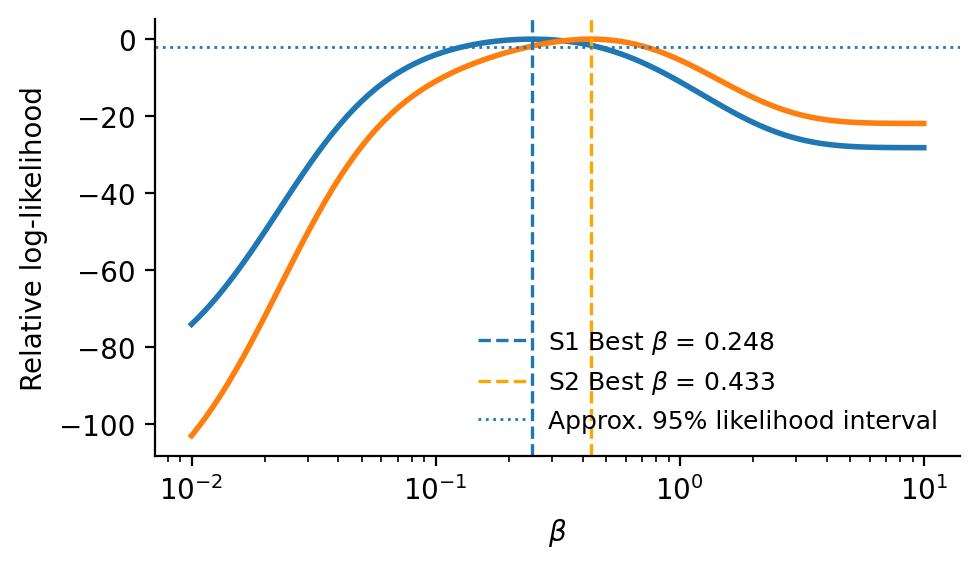

In [62]:
fig, ax = plt.subplots(
    figsize=(5, 3)
)

ax.plot(
    fit_results1["beta"],
    fit_results1["delta_logLik"],
    linewidth=2
)
ax.plot(
    fit_results2["beta"],
    fit_results2["delta_logLik"],
    linewidth=2
)

best_idx = valid_results1["logLik"].idxmax()
best_row = valid_results1.loc[best_idx]
best_beta = best_row["beta"]
ax.axvline(
    best_beta,
    linestyle="--",
    linewidth=1.2,
    label=fr"S1 Best $\beta$ = {best_beta:.3g}"
)

best_idx = valid_results2["logLik"].idxmax()
best_row = valid_results2.loc[best_idx]
best_beta = best_row["beta"]
ax.axvline(
    best_beta,
    linestyle="--",
    linewidth=1.2,
    label=fr"S2 Best $\beta$ = {best_beta:.3g}",
    c='orange'
)

ax.axhline(
    -1.92,
    linestyle=":",
    linewidth=1,
    label="Approx. 95% likelihood interval"
)

ax.set_xscale("log")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Relative log-likelihood")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=9,
)

fig.tight_layout()
plt.show()

### Bootstrap

In [16]:
betas = np.logspace(-1.5, 0.5, 100)
session = 'S2'
n_iter = 500
adjacency, community, node_degree = build_exp_graph()

subj_full = list(range(121, 155))
idx_remov = [128, 134, 140, 144, 152]
subj_list = [x for x in subj_full if x not in idx_remov]

# bootstrap
bootstrap_records = []
profile_records = []
rng = np.random.default_rng(123)

for iter in range(n_iter):
    sampled_subj = rng.choice(subj_list,
                              size=len(subj_list),
                              replace=True)
    iter_records = []
    
    for beta in tqdm(betas, desc=f'Bootstrap {iter+1}/{n_iter}'):
        full_tbl  = simulate_analytic_one_beta(beta, 
                                               subj_list, 
                                               adjacency, 
                                               community,
                                               session)
        resampled_tbl = bootstrap_subject(full_tbl, sampled_subj)
        fit_result = fit_one_beta(resampled_tbl)
        iter_records.append({
            "iteration": iter,
            "beta": float(beta),
            **fit_result
        })
    
    # 当前 bootstrap iteration 的 beta likelihood profile
    iter_profile = pd.DataFrame(iter_records)

    profile_records.append(iter_profile)

    valid_profile = iter_profile.loc[
        np.isfinite(iter_profile["logLik"])
    ].copy()

    if valid_profile.empty:
        bootstrap_records.append({
            "iteration": iter,
            "best_beta": np.nan,
            "max_logLik": np.nan,
            "n_unique_subjects": len(
                np.unique(sampled_subj)
            ),
            "boundary_hit": False
        })

        continue

    best_idx = valid_profile["logLik"].idxmax()
    best_row = valid_profile.loc[best_idx]

    best_beta = float(best_row["beta"])

    bootstrap_records.append({
        "iteration": iter,
        "best_beta": best_beta,
        "max_logLik": float(best_row["logLik"]),
        "n_unique_subjects": len(
            np.unique(sampled_subj)
        ),
        "boundary_hit": bool(
            np.isclose(best_beta, betas[0])
            or np.isclose(best_beta, betas[-1])
        )
    })


Bootstrap 500/500: 100%|██████████| 100/100 [00:36<00:00,  2.72it/s]


In [17]:
bootstrap_results = pd.DataFrame(
    bootstrap_records
)

bootstrap_profiles = pd.concat(
    profile_records,
    ignore_index=True
)

valid_boot = bootstrap_results.loc[
    np.isfinite(bootstrap_results["best_beta"])
].copy()

beta_quantiles = np.quantile(
    valid_boot["best_beta"],
    [0.025, 0.5, 0.975]
)

print(f"Median beta: {beta_quantiles[1]:.6f}")
print(
    "95% bootstrap interval: "
    f"[{beta_quantiles[0]:.6f}, "
    f"{beta_quantiles[2]:.6f}]"
)

Median beta: 0.448245
95% bootstrap interval: [0.168761, 0.859693]


In [ ]:
# store variables

# with open('bootstrap_result_s2.pkl', 'wb') as f:
#     pickle.dump({'bootstrap_results': bootstrap_results, 
#                  'bootstrap_profiles': bootstrap_profiles}, 
#                 f)

In [22]:
# read variables

with open("bootstrap_result_s1.pkl", "rb") as f:
    saved = pickle.load(f)

bootstrap_results_s1 = saved["bootstrap_results"]
bootstrap_profiles_s1 = saved["bootstrap_profiles"]

with open("bootstrap_result_s2.pkl", "rb") as f:
    saved = pickle.load(f)

bootstrap_results_s2 = saved["bootstrap_results"]
bootstrap_profiles_s2 = saved["bootstrap_profiles"]



valid_boot_s1 = bootstrap_results_s1.loc[
    np.isfinite(bootstrap_results_s1["best_beta"])
].copy()

beta_quantiles_s1 = np.quantile(
    valid_boot_s1["best_beta"],
    [0.025, 0.5, 0.975]
)

valid_boot_s2 = bootstrap_results_s2.loc[
    np.isfinite(bootstrap_results_s2["best_beta"])
].copy()

beta_quantiles_s2 = np.quantile(
    valid_boot_s2["best_beta"],
    [0.025, 0.5, 0.975]
)

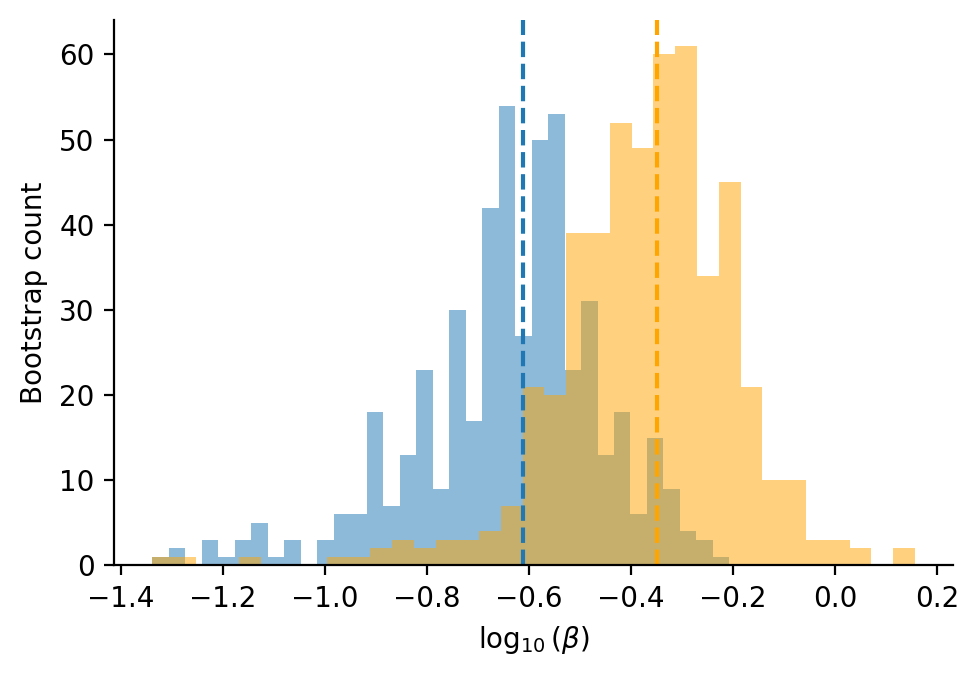

In [30]:
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.hist(
    np.log10(valid_boot_s1["best_beta"]),
    bins=35,
    alpha=0.5
)

ax.hist(
    np.log10(valid_boot_s2["best_beta"]),
    bins=35,
    color='orange',
    alpha=0.5
)

ax.axvline(
    np.log10(beta_quantiles_s1[1]),
    linestyle="--",
    linewidth=1.5
)

ax.axvline(
    np.log10(beta_quantiles_s2[1]),
    linestyle="--",
    linewidth=1.5,
    c = 'orange'
)

ax.set_xlabel(r"$\log_{10}(\beta)$")
ax.set_ylabel("Bootstrap count")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [32]:
# stats
paired_boot = (
    valid_boot_s1[["iteration", "best_beta"]]
    .rename(columns={"best_beta": "best_beta_s1"})
    .merge(
        valid_boot_s2[["iteration", "best_beta"]]
        .rename(columns={"best_beta": "best_beta_s2"}),
        on="iteration",
        how="inner",
        validate="one_to_one"
    )
)

paired_boot = paired_boot.loc[
    (paired_boot["best_beta_s1"] > 0)
    & (paired_boot["best_beta_s2"] > 0)
].copy()

paired_boot["log_beta_s1"] = np.log10(
    paired_boot["best_beta_s1"]
)

paired_boot["log_beta_s2"] = np.log10(
    paired_boot["best_beta_s2"]
)

paired_boot["delta_log_beta"] = (
    paired_boot["log_beta_s2"]
    - paired_boot["log_beta_s1"]
)

delta_quantiles = np.quantile(
    paired_boot["delta_log_beta"],
    [0.025, 0.5, 0.975]
)

delta_low, delta_median, delta_high = delta_quantiles

print(f"Median Δlog10(beta), S2-S1: {delta_median:.4f}")
print(
    "95% bootstrap interval: "
    f"[{delta_low:.4f}, {delta_high:.4f}]"
)

Median Δlog10(beta), S2-S1: 0.2424
95% bootstrap interval: [0.0000, 0.6667]


In [37]:
from scipy import stats

nonzero_delta = paired_boot.loc[
    paired_boot["delta_log_beta"] != 0,
    "delta_log_beta"
]

if len(nonzero_delta) > 0:
    wilcox_result = stats.wilcoxon(
        nonzero_delta,
        alternative="two-sided",
        zero_method="wilcox"
    )

    print(
        f"Wilcoxon signed-rank: "
        f"W = {wilcox_result.statistic:.4f}"
    )
    print(
        f"Wilcoxon signed-rank: "
        f"p = {wilcox_result.pvalue:.4g}"
    )
else:
    print("All paired beta differences are zero.")

Wilcoxon signed-rank: W = 384.0000
Wilcoxon signed-rank: p = 3.875e-82


In [ ]:
# 画出最佳 beta的prediction

In [ ]:
# trial_order = ['within_legal',
#             'between_legal',
#             'within_illegal',
#             'between_illegal']
# measure = 'p_yes'
# dat4plot = (
#     sim_s1.groupby(['trial_type'], as_index=False)
#     .agg(mean_dat = (measure, 'mean'),
#          sd_dat = (measure, 'std'),
#          n_trial = (measure, 'count'))
# )

# dat4plot['trial_type'] = pd.Categorical(
#     dat4plot['trial_type'],
#     categories=trial_order,
#     ordered=True
# )

# dat4plot = dat4plot.sort_values('trial_type').reset_index(drop=True)

# # plot figures
# fig, ax = plt.subplots(figsize=(3, 2.5))
# x=np.arange(len(dat4plot))
# ax.bar(
#     x, 
#     dat4plot['mean_dat'],
#     # yerr=dat4plot['se_dat'],
#     width=0.4,
#     color=my_color,
#     capsize=5,
#     error_kw={
#         "elinewidth": 1.5,
#         "capthick": 1.5
#     },
# )
# ax.set_xticks(x)
# ax.set_xticklabels(
#     [
#         "Within-legal",
#         "Between-legal",
#         "Within-illegal",
#         "Between-illegal",
#     ],
#     rotation=20,
#     ha='right'
# )

# ax.set_xlabel("Trial type")
# ax.set_ylabel(measure)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.tight_layout()